In [39]:
import pandas as pd
from torch.utils.data import DataLoader
import numpy as np 
from PIL import Image
import matplotlib.pyplot as plt

In [40]:
from torchvision.datasets import MNIST
from torchvision.transforms import transforms
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.3],[0.3])
])

In [41]:
xtr=MNIST('./data',download=True,train=True,target_transform=transform)
xter=MNIST('./data',download=False,train=False,target_transform=transform)
y=xtr.targets
xtr=xtr.data/255
yte=xter.targets
xter=xter.data/255

In [42]:
xtr[0]

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

tensor(5)


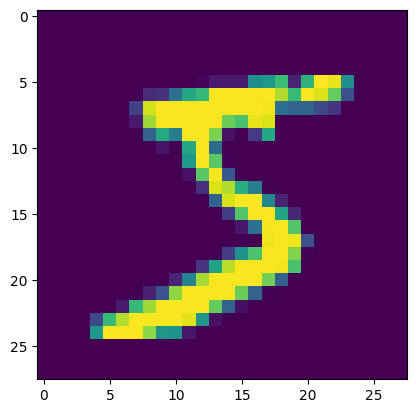

In [43]:
plt.imshow(xtr[0])
print(y[0])
newy=np.zeros((60000,10))
c=0
for i in y:
    newy[c][i]=1
    c+=1
c=0
ytest=np.zeros((10000,10))
for i in yte:
    ytest[c][i]=1
    c+=1

In [44]:
newy[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [45]:
def initialize_params(Lis):
    params={}
    for i in range(1,len(Lis)):
        params['W'+str(i)]=np.random.random((Lis[i-1],Lis[i]))
        params['b'+str(i)]=np.random.random((Lis[i],1))
    return params

In [46]:
Lis=[28*28,120,64,10]
params=initialize_params(Lis)

In [47]:
params

{'W1': array([[0.83535944, 0.30225225, 0.39943123, ..., 0.29811341, 0.62767113,
         0.7753446 ],
        [0.62678153, 0.05846258, 0.10623702, ..., 0.279024  , 0.94987665,
         0.13865051],
        [0.27790515, 0.26176167, 0.52442217, ..., 0.98582723, 0.85771675,
         0.30645698],
        ...,
        [0.00549624, 0.97760368, 0.57718052, ..., 0.89681386, 0.32463989,
         0.76032508],
        [0.73212072, 0.72725691, 0.15935955, ..., 0.14975511, 0.46089026,
         0.2861274 ],
        [0.07736994, 0.45766659, 0.51220839, ..., 0.82231583, 0.43400932,
         0.7470206 ]], shape=(784, 120)),
 'b1': array([[0.14098988],
        [0.83010579],
        [0.54324553],
        [0.2749521 ],
        [0.12425509],
        [0.69512833],
        [0.08358819],
        [0.16866381],
        [0.37459936],
        [0.26315176],
        [0.69746062],
        [0.17190236],
        [0.30328174],
        [0.16937729],
        [0.13097303],
        [0.25079596],
        [0.96087103],
     

In [48]:
def ReLU(k):
    for i in range(k.shape[0]):
        for j in range(k.shape[1]):
            if k[i,j]<0:
                k[i,j]=0
    return k
def softmax(k):
    nk=k-np.max(k)
    exps=np.exp(nk)
    return exps/np.sum(exps)     
def softmax_derivative(k):
    s=softmax(k).reshape(-1,1)
    return np.diagflat(s)-np.dot(s,s.T)
  

In [49]:
xtr[0]

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

In [50]:
def forwardr(x,w,b):
    return ReLU(np.dot(x,w)+b)
def forwards(x,w,b):
    return softmax(np.dot(x,w)+b)


In [51]:
def forward_pass(x,params,Lis):
    a=[]
    a.append(x)
    for i in range(1,len(Lis)-1):
        a.append(forwardr(a[i-1],params['W'+str(i)],params['b'+str(i)].T))
    le=len(Lis)-1
    a.append(forwards(a[le-1],params['W'+str(le)],params['b'+str(le)].T))
    return a

In [52]:
yp=forward_pass(np.array([xtr[0]]).reshape(1,-1),params,Lis)

In [53]:
def relu_derivative(a):
    return (a > 0).astype(float)

In [56]:
yp[1].shape,params['W2'].shape

((1, 120), (120, 64))

In [57]:
def loss_function(y_real,y_predict):
    return (y_real-y_predict)**2
def loss_function1(y_real,y_predict):
    return -np.sum(y_real*np.log(y_predict))

In [58]:
eta=2e-2

In [59]:
params['W3'].shape

(64, 10)

In [60]:
for i in params:
    print(f'{i} : {params[i].shape}')

W1 : (784, 120)
b1 : (120, 1)
W2 : (120, 64)
b2 : (64, 1)
W3 : (64, 10)
b3 : (10, 1)


In [62]:
params

{'W1': array([[0.83535944, 0.30225225, 0.39943123, ..., 0.29811341, 0.62767113,
         0.7753446 ],
        [0.62678153, 0.05846258, 0.10623702, ..., 0.279024  , 0.94987665,
         0.13865051],
        [0.27790515, 0.26176167, 0.52442217, ..., 0.98582723, 0.85771675,
         0.30645698],
        ...,
        [0.00549624, 0.97760368, 0.57718052, ..., 0.89681386, 0.32463989,
         0.76032508],
        [0.73212072, 0.72725691, 0.15935955, ..., 0.14975511, 0.46089026,
         0.2861274 ],
        [0.07736994, 0.45766659, 0.51220839, ..., 0.82231583, 0.43400932,
         0.7470206 ]], shape=(784, 120)),
 'b1': array([[0.14098988],
        [0.83010579],
        [0.54324553],
        [0.2749521 ],
        [0.12425509],
        [0.69512833],
        [0.08358819],
        [0.16866381],
        [0.37459936],
        [0.26315176],
        [0.69746062],
        [0.17190236],
        [0.30328174],
        [0.16937729],
        [0.13097303],
        [0.25079596],
        [0.96087103],
     

In [63]:
relu_derivative(yp[2])

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [64]:
yp[3][0].shape,newy[0].shape

((10,), (10,))

In [65]:
def relu_derivative(a):
    return (a > 0).astype(float)
def update(params,x,y,eta,Lis):
    yp=forward_pass(x,params,Lis)
    a0=yp[0]      
    a1=yp[1]   
    a2=yp[2] 
    y_hat=yp[3] 
    delta3=y_hat-y                
    dW3=a2.T@delta3                
    db3=delta3                       
    delta2=(delta3 @ params['W3'].T)*relu_derivative(a2)
    dW2=a1.T @ delta2                
    db2=delta2                       
    delta1=(delta2 @ params['W2'].T)*relu_derivative(a1)
    dW1=a0.T@delta1                
    db1=delta1                       
    params['W3']-=eta*dW3
    params['b3']-=eta*db3.reshape(params['b3'].shape)
    params['W2']-=eta*dW2
    params['b2']-=eta*db2.reshape(params['b2'].shape)
    params['W1']-=eta*dW1
    params['b1']-=eta*db1.reshape(params['b1'].shape)
    return params

In [66]:
eta=1e-4

In [67]:
params=initialize_params(Lis)

In [68]:
xtr.shape[0]

60000

In [69]:
def categorical_cross_entropy(y_hat,y):
    epsilon=1e-15
    y_hat=np.clip(y_hat,epsilon,1-epsilon)
    loss=-np.sum(y*np.log(y_hat),axis=-1)
    return np.mean(loss)

In [71]:
epoch=22
for j in range(epoch):
    total_loss=0
    for i in range(xtr.shape[0]):
        yp=forward_pass(np.array([xtr[i]]).reshape(1,-1),params,Lis)
        update(params,np.array([xtr[i]]).reshape(1,-1),newy[i],eta,Lis)
        loss=categorical_cross_entropy(newy[i],yp[3][0])
        total_loss+=loss
    print(f'Cross entroy loss for the {j}th Pass :',total_loss)

Cross entroy loss for the 0th Pass : 1123366.029272529
Cross entroy loss for the 1th Pass : 770608.3037371417
Cross entroy loss for the 2th Pass : 646660.2032695062
Cross entroy loss for the 3th Pass : 570920.9309738044
Cross entroy loss for the 4th Pass : 523620.1134441585
Cross entroy loss for the 5th Pass : 490662.308573878
Cross entroy loss for the 6th Pass : 464729.538942386
Cross entroy loss for the 7th Pass : 444264.1449683907
Cross entroy loss for the 8th Pass : 427302.2102660332
Cross entroy loss for the 9th Pass : 412498.24881418206
Cross entroy loss for the 10th Pass : 400797.8512222604
Cross entroy loss for the 11th Pass : 390667.0380892296
Cross entroy loss for the 12th Pass : 381043.6466583966
Cross entroy loss for the 13th Pass : 372358.37913205795
Cross entroy loss for the 14th Pass : 364731.8623739618
Cross entroy loss for the 15th Pass : 357378.5173452051
Cross entroy loss for the 16th Pass : 351310.92176776007
Cross entroy loss for the 17th Pass : 346119.2420772379
C

In [ ]:
c=0
for p in range(10000):
    yp=forward_pass(np.array([xter[p]]).reshape(1,-1),params,Lis)
    if np.argmax(yp[3][0])!=np.argmax(ytest[p]):
        c+=1
print(c)

6 5 8
6 4 33
4 9 62
8 9 73
7 2 77
9 7 80
4 9 92
3 7 97
2 7 114
9 7 124
2 0 126
9 7 144
8 2 149
3 9 151
0 5 152
3 2 172
3 7 175
4 9 185
3 5 187
7 5 211
8 6 217
3 5 219
3 9 241
5 3 245
2 4 247
3 7 255
0 6 259
1 5 261
4 9 264
4 8 290
3 8 299
6 4 300
3 7 301
8 7 307
3 2 318
3 9 320
3 2 321
9 4 325
3 5 340
4 6 341
8 5 347
0 5 352
9 7 358
3 2 362
3 5 367
9 8 403
3 5 412
3 4 432
3 8 435
5 0 443
8 2 444
0 6 445
8 9 448
3 7 468
8 5 478
3 9 479
0 5 483
8 4 497
3 5 502
5 3 507
8 4 511
9 7 522
4 9 530
6 3 531
3 8 542
3 8 543
3 7 550
3 7 551
6 8 553
9 4 565
8 3 578
3 8 582
3 8 591
3 8 606
6 4 610
8 2 613
3 1 619
8 2 624
4 9 627
9 2 659
5 0 661
3 7 667
3 5 674
3 7 684
4 8 691
9 4 707
3 5 710
8 5 720
9 7 726
8 2 728
8 2 738
9 4 740
3 2 741
3 5 751
3 7 756
9 4 760
9 7 771
5 8 781
9 5 791
8 5 797
2 7 810
6 2 823
3 8 839
3 8 844
9 7 846
3 5 857
6 8 877
9 4 881
3 7 898
3 2 922
8 2 926
8 7 930
5 3 938
0 2 939
2 7 950
4 5 951
3 1 956
0 6 965
3 2 975
3 2 990
3 5 1003
5 6 1014
9 5 1022
6 4 1023
6 5 1032
3 8 

In [73]:
np.savez("params.npz",**params)

In [ ]:
## loaded_data=np.load("model_weights.npz")
## params={key:loaded_data[key] for key in loaded_data.files}